# 03 · When Indonesia grows it

**Data gap, stated up front:** FAOSTAT's QCL/QI/QV are **annual** — there is no month-level planting/harvest data in anything already downloaded in this repo. This notebook does two things instead of faking a calendar:

1. A real proxy available from existing data: **cropping intensity** (area harvested ÷ arable land). A ratio meaningfully above 100% signals multiple harvests per year on the same land — which for Indonesian rice is a genuine, well-documented pattern (2–3 seasons/year in much of Java).
2. A pointer to the dataset that *would* give exact planting/harvest months, if this angle is worth pursuing further: FAO's **Crop Calendar** tool (https://www.fao.org/agriculture/seed/cropcalendar/), not bundled with the bulk downloads and not currently in this repo.

## Setup

In [1]:
import sys; sys.path.append('..')
import pandas as pd, matplotlib.pyplot as plt
from src.load import load_indonesia, load_landuse_indonesia
from src.clean import drop_item_aggregates, drop_permanent_crops
from src import viz

qcl = load_indonesia('QCL')
land = load_landuse_indonesia()
print('land use available:', land is not None)

[cache] QCL_indonesia_2010_2024.parquet


[cache] RL_indonesia.parquet
land use available: True


## Cropping intensity — temporary-crop area harvested vs arable land
If well above 100%, the same arable land is being planted more than once a year. Restricted to **temporary crops only** (drops roll-up aggregates and permanent tree/shrub crops like oil palm, coconut, cocoa, coffee — those sit on separate "permanent cropland", not "arable land", by FAO's own definition, so mixing them in would overstate the ratio).

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/cropping_intensity_over_time.png


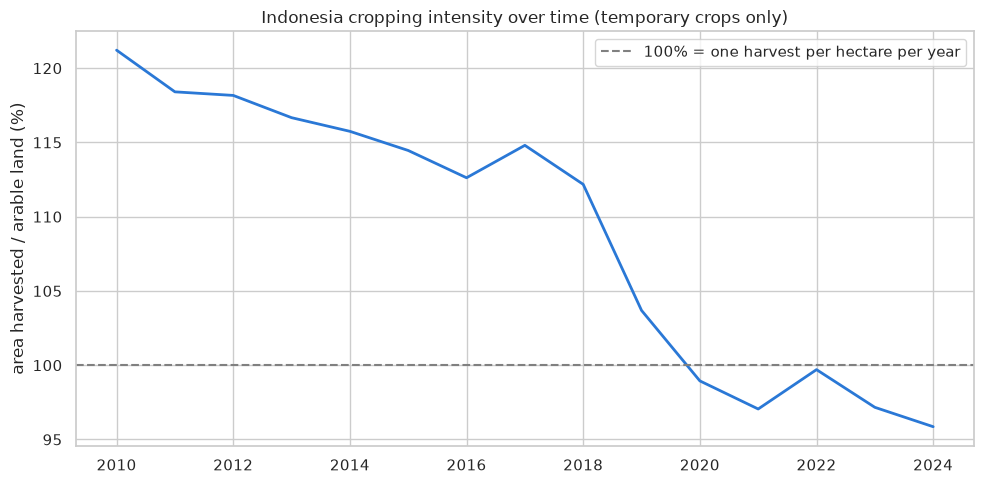

    year  area_harvested_ha  arable_land_1000ha  cropping_intensity_pct
5   2015         20419785.0            17840.57              114.457021
6   2016         20082717.0            17832.20              112.620524
7   2017         20462403.0            17823.83              114.803625
8   2018         19984886.0            17815.46              112.177210
9   2019         18464051.0            17807.09              103.689323
10  2020         17610636.0            17798.72               98.943272
11  2021         17265738.0            17790.35               97.051143
12  2022         17728917.0            17781.98               99.701591
13  2023         17278573.0            17782.90               97.163978
14  2024         16960967.0            17693.66               95.859008


In [2]:
if land is not None:
    arable = land[(land['Item'] == 'Arable land') & (land['Element'] == 'Area')][['year', 'value']]
    arable = arable.rename(columns={'value': 'arable_land_1000ha'})

    ah = qcl[qcl['Element'] == 'Area harvested']
    ah = drop_item_aggregates(ah)      # exclude roll-up totals (double counting)
    ah = drop_permanent_crops(ah)      # exclude oil palm/coconut/etc. (not arable land)
    harvested = ah.groupby('year')['value'].sum().rename('area_harvested_ha').reset_index()

    intensity = harvested.merge(arable, on='year', how='inner')
    # Area harvested is in ha, Arable land is in 1000 ha -> convert to matching units.
    intensity['cropping_intensity_pct'] = (
        100 * intensity['area_harvested_ha'] / (intensity['arable_land_1000ha'] * 1000)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(intensity['year'], intensity['cropping_intensity_pct'], color='#2a78d6', linewidth=2)
    ax.axhline(100, ls='--', c='grey', label='100% = one harvest per hectare per year')
    ax.set_title('Indonesia cropping intensity over time (temporary crops only)')
    ax.set_ylabel('area harvested / arable land (%)')
    ax.legend()
    fig.tight_layout()
    viz.save(fig, 'cropping_intensity_over_time')
    plt.show()
    print(intensity.tail(10))
else:
    print('Land Use data not available — see src/load.load_landuse_indonesia docstring.')

## Rice specifically — is multi-cropping visible?
Rice area harvested well above rice-suitable arable land area would itself suggest 2+ seasons/year, independent of the aggregate ratio above.

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_rice_area_harvested_over_time.png


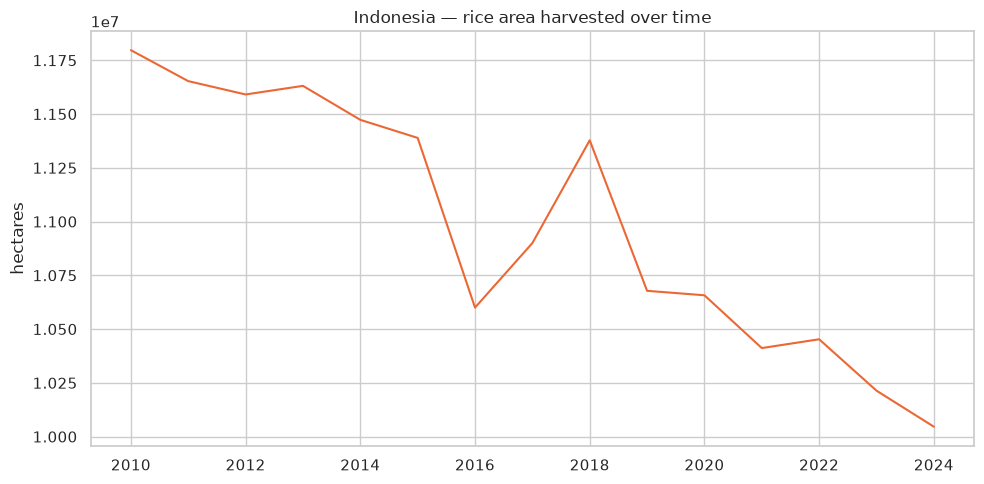

In [3]:
rice_area = qcl[(qcl['Item'] == 'Rice') & (qcl['Element'] == 'Area harvested')][['year', 'value']]
rice_area = rice_area.rename(columns={'value': 'rice_area_harvested'})
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rice_area['year'], rice_area['rice_area_harvested'], color='#eb6834')
ax.set_title('Indonesia — rice area harvested over time')
ax.set_ylabel('hectares')
fig.tight_layout()
viz.save(fig, 'idn_rice_area_harvested_over_time')
plt.show()

## Summary

- **Cropping intensity:** … (fill in after running — is it rising, and is it above 100%, consistent with multi-season rice cultivation?)
- **What this notebook can't tell you:** which months planting/harvest happen in, or how that varies by island/province. That needs FAO's Crop Calendar data (see gap note above) — flag this as a follow-up download if the "when" angle becomes the project focus.
- Next: `04_synthesis` — pull the what/when findings together.